
# 01 b Decision Trees in Anamnesis

In [ ]:
import pandas as pd


# Read CSV
df = pd.read_csv("../Data/Electronic_Health_Record/EHR.csv")


<>:5: SyntaxWarning: invalid escape sequence '\D'
<>:5: SyntaxWarning: invalid escape sequence '\D'
C:\Users\BNHOLLAUS\AppData\Local\Temp\ipykernel_21400\3017306314.py:5: SyntaxWarning: invalid escape sequence '\D'
  df = pd.read_csv("..\Data\Electronic_Health_Record\EHR.csv")


,patientunitstayid,patienthealthsystemstayid,hospitalid,wardid,admissionheight,hospitaladmitoffset,hospitaldischargeyear,hospitaldischargeoffset,unitvisitnumber,admissionweight,dischargeweight,unitdischargeoffset
count,1.447000e+03,1447.000000,1447.000000,1447.000000,1402.000000,1447.000000,1447.000000,1447.000000,1447.000000,1313.000000,871.000000,1447.000000
mean,6.464812e+05,494962.955079,139.385625,301.238424,168.061591,-2133.019350,2014.651693,8565.659295,1.186593,82.985773,84.457991,3840.753283
std,3.855454e+05,269873.698956,52.179555,158.898758,13.442189,8498.257236,0.476599,9848.458042,0.477444,24.965156,25.173490,5893.674584
min,1.424930e+05,129943.000000,69.000000,85.000000,1.600000,-251404.000000,2014.000000,-62.000000,1.000000,10.000000,35.100000,0.000000
25%,2.647495e+05,227611.500000,92.000000,136.000000,160.000000,-1523.000000,2014.000000,2747.000000,1.000000,65.700000,67.155000,1273.000000
50%,4.212490e+05,359321.000000,112.000000,252.000000,167.600000,-220.000000,2015.000000,5724.000000,1.000000,78.100000,80.030000,2366.000000
75%,1.056172e+06,782773.500000,194.000000,467.000000,177.800000,-42.500000,2015.000000,10213.000000,1.000000,97.700000,99.650000,4303.000000
max,1.135186e+06,842932.000000,199.000000,495.000000,297.180000,4031.000000,2015.000000,133974.000000,5.000000,262.400000,249.800000,119276.000000


Having a closer look at the data, we see that we have the following column names:

In [4]:
print(df.columns)

Index(['patientunitstayid', 'patienthealthsystemstayid', 'gender', 'age',
       'ethnicity', 'hospitalid', 'wardid', 'apacheadmissiondx',
       'admissionheight', 'hospitaladmittime24', 'hospitaladmitoffset',
       'hospitaladmitsource', 'hospitaldischargeyear',
       'hospitaldischargetime24', 'hospitaldischargeoffset',
       'hospitaldischargelocation', 'hospitaldischargestatus', 'unittype',
       'unitadmittime24', 'unitadmitsource', 'unitvisitnumber', 'unitstaytype',
       'admissionweight', 'dischargeweight', 'unitdischargetime24',
       'unitdischargeoffset', 'unitdischargelocation', 'unitdischargestatus',
       'uniquepid'],
      dtype='str')


We could try to make a decision based model for a specific hospital

In [5]:
# Find the most common hospital ID
most_common_hospital = df['hospitalid'].value_counts().idxmax()
count = df['hospitalid'].value_counts().max()

print(f"Most common hospital ID: {most_common_hospital} (appears {count} times)")

Most common hospital ID: 182 (appears 89 times)


As it seems hospital 182 is in the dataset the most often we try to understand, how they decide what to do. Age, gender, ethnicity, admissionhight and admissionweight and how this is connected to the unittype

First we need to take care of the age column and encode the string based inputs

In [14]:
import numpy as np

# Replace '>89' with random integers between 89 and 100
df['age'] = df['age'].apply(
    lambda x: np.random.randint(89, 101) if x == '> 89' else x
)

# Convert age column to numeric
df['age'] = pd.to_numeric(df['age'])

from sklearn.preprocessing import LabelEncoder

df_copy = df.copy()


for col in ["gender", "ethnicity", "unittype"]:
    le = LabelEncoder()
    df_copy[col] = le.fit_transform(df_copy[col].astype(str))

df_copy.head()

,patientunitstayid,patienthealthsystemstayid,gender,age,ethnicity,hospitalid,wardid,apacheadmissiondx,admissionheight,hospitaladmittime24,...,unitadmitsource,unitvisitnumber,unitstaytype,admissionweight,dischargeweight,unitdischargetime24,unitdischargeoffset,unitdischargelocation,unitdischargestatus,uniquepid
0,210014,182373,1,45.0,2,73,89,"Hypertension, uncontrolled (for cerebrovascula...",178.0,13:08:59,...,Direct Admit,1,admit,116.0,112.7,15:00:00,4424,Skilled Nursing Facility,Alive,002-10665
1,200026,174624,1,50.0,2,71,87,Ablation or mapping of cardiac conduction pathway,177.8,10:41:00,...,Operating Room,1,admit,106.1,106.1,17:40:00,1548,Home,Alive,002-10715
2,221131,190993,1,83.0,2,71,87,"Endarterectomy, carotid",175.3,21:43:00,...,Operating Room,1,admit,NaN,72.1,17:46:00,1203,Home,Alive,002-10249
3,221215,191054,1,49.0,2,71,87,"Infarction, acute myocardial (MI)",185.4,03:16:00,...,Emergency Department,1,admit,145.3,146.6,19:07:00,1562,Home,Alive,002-10627
4,217835,188445,1,57.0,2,73,92,"CABG alone, coronary artery bypass grafting",172.7,01:09:00,...,Operating Room,1,admit,NaN,80.4,08:25:00,4719,Floor,Alive,002-10324


In a second step we need to filter for hospital 152

In [17]:
# Filter the dataframe for hospital ID 182
df_hospital_182 = df_copy[df_copy['hospitalid'] == most_common_hospital]
print(df_hospital_182)

      patientunitstayid  patienthealthsystemstayid  gender   age  ethnicity  \
49               962222                     708354       1  41.0          0   
50               962223                     708354       1  41.0          0   
51               963941                     709735       0  94.0          2   
52               963942                     709735       0  97.0          2   
53               964577                     710250       0  78.0          2   
...                 ...                        ...     ...   ...        ...   
1094             975217                     718816       0  82.0          2   
1095             975298                     718884       0  72.0          2   
1096             975328                     718908       0  77.0          2   
1097             975646                     719165       0  73.0          2   
1098             978454                     721416       0  97.0          2   

      hospitalid  wardid                           

Then we get rid of all the columns that are not in our interest

In [18]:
# Extract the specified columns from df_copy
features = df_hospital_182[['age', 'gender', 'ethnicity', 'admissionheight', 'admissionweight', 'unittype']]
features.head()

,age,gender,ethnicity,admissionheight,admissionweight,unittype
49,41.0,1,0,172.7,110.40,5
50,41.0,1,0,172.7,110.40,5
51,94.0,0,2,154.9,69.50,5
52,97.0,0,2,154.9,68.03,5
53,78.0,0,2,165.1,54.40,5


Now we can do the Decision tree. Remeber Age, Gender, Ethnicity, Hight and Weight is input. Unittype is the output.

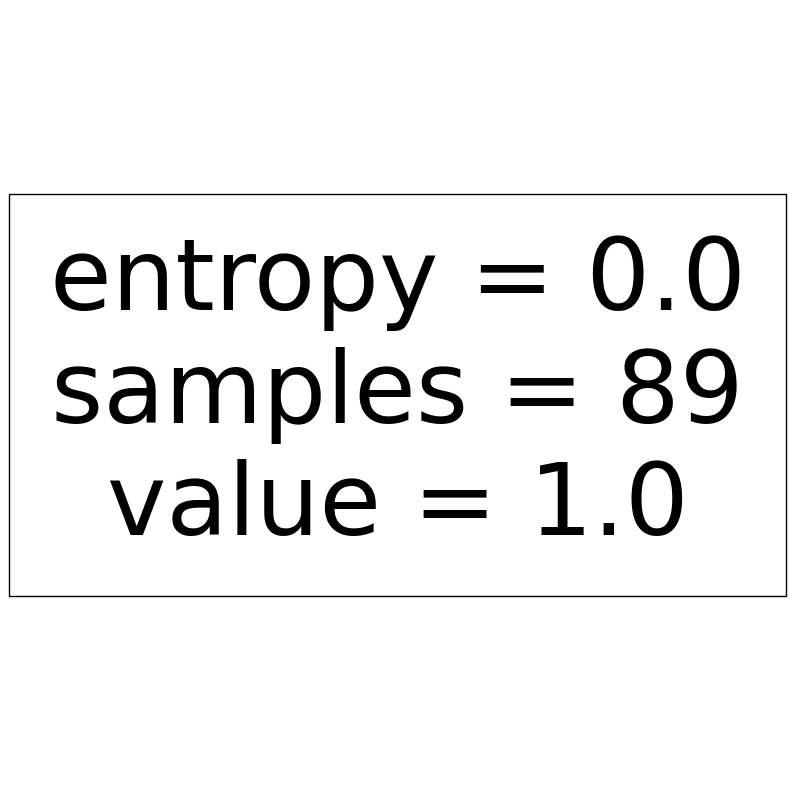

In [19]:
from sklearn import tree
from matplotlib import pyplot as plt

X = features[['age', 'gender', 'ethnicity', 'admissionheight', 'admissionweight']]
y = features['unittype']

clf = tree.DecisionTreeClassifier(criterion='entropy', max_depth=4, min_samples_leaf=1)
clf.fit(X, y)

fig, ax = plt.subplots(figsize=(10, 10))
tree.plot_tree(clf, ax=ax, feature_names=X.columns, class_names=[str(i) for i in sorted(y.unique())])
plt.show()

Well, why is that? --> We do not have a tree but a fundamental decision in general. All Patients are assigned to unittype 5. 

This can be explained by the fact, that hospital 152 only has a unit 5. Therefore all patients can only be assigned to unittype 5.

Lets try to do an overall analysis then. What if we do not filter for hospital 152?

In [25]:
from sklearn import tree
from matplotlib import pyplot as plt

X = df_copy[['age', 'gender', 'ethnicity', 'admissionheight', 'admissionweight']]
y = df_copy['unittype']

clf = tree.DecisionTreeClassifier(criterion='entropy', max_depth=4, min_samples_leaf=1)
clf.fit(X, y)

fig, ax = plt.subplots(figsize=(100, 100))
tree.plot_tree(clf, ax=ax, feature_names=X.columns, class_names=[str(i) for i in sorted(y.unique())])
plt.show()

Ethnicity is the main decider to which unittype patients are assigned to.

TASK: 

* Discuss why that is the case?
* Discuss what mistakes we made along the way?
* Try to fix some of the mistakes